<a href="https://colab.research.google.com/github/nunotfc-png/Caeser-Cipher/blob/master/EX03_Market_Basket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX03 — Análise do Cabaz de Compras (MBA)
**UC: Análise de Dados de Negócio** · Aula 2

---

Regras de associação com Apriori e FP-Growth. Support, confidence, lift. Visualização e comparação de algoritmos.

**Dataset:** Online Retail II (UCI ML Repository)  
**URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

**Outputs gerados:** `regras_associacao.csv` · `top_produtos.csv` · `mba_rules.png`


In [1]:
# @title ⚙️ Instalação de Dependências (executar uma vez por sessão)

!pip install -q mlxtend

In [2]:
# Dataset: Online Retail II (mesmo do EX01)
# Biblioteca: mlxtend (implementação Apriori / FP-Growth)
# pip install mlxtend
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GREEN = '#0891B2', '#0D9488'

In [3]:
# Se não usar Drive, os ficheiros ficam em /content/ (sessão temporária):
OUTPUT_DIR = '/content/'
print(f"Directório de output: {OUTPUT_DIR}")

Directório de output: /content/


## PARTE 1 — CARREGAMENTO E PREPARAÇÃO

In [4]:
# Reutilizar o dataset do EX01 (Online Retail II)
# Se já tiver o ficheiro local, usa: df = pd.read_excel('online_retail_II.xlsx', ...)
df_raw = pd.read_excel(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx',
    sheet_name='Year 2010-2011'
)

df_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Análise Exploratória Simples
print("Shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.info())
print(df_raw.isnull().sum())

Shape: (541910, 8)
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----

In [6]:
# Limpeza
df = df_raw.copy()
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df.dropna(subset=['Customer ID', 'Description'])
df = df[df['Quantity'] > 0]

# Focar no mercado do Reino Unido para ter volume suficiente
df_uk = df[df['Country'] == 'United Kingdom']
print(f"Transacções UK: {df_uk['Invoice'].nunique()}")
print(f"Produtos únicos: {df_uk['Description'].nunique()}")

Transacções UK: 16649
Produtos únicos: 3844


## PARTE 2 — CONSTRUÇÃO DA MATRIZ BINÁRIA DE TRANSACÇÕES

In [7]:
# Pivot: linhas = fatura, colunas = produto, valores = 0/1
basket = (
    df_uk.groupby(['Invoice', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

# Converter para binário
basket_bin = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"\nDimensão da matriz basket: {basket_bin.shape}")
print(f"Densidade: {basket_bin.values.mean():.4f} (fração de células =1)")

basket_bin.head()


Dimensão da matriz basket: (16649, 3844)
Densidade: 0.0054 (fração de células =1)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## PARTE 3 — APRIORI E ITEMSETS FREQUENTES

In [8]:
# Nota: support mínimo é sensível ao dataset — começar conservador
MIN_SUPPORT   = 0.02   # ← experimenta 0.01, 0.03, 0.05
MIN_CONFIDENCE = 0.3
MIN_LIFT       = 1.5

frequent_items = apriori(
    basket_bin,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3          # conjuntos até 3 itens
)
frequent_items['length'] = frequent_items['itemsets'].apply(len)

print(f"\nItemsets frequentes encontrados: {len(frequent_items)}")
print(frequent_items.sort_values('support', ascending=False).head(15))


Itemsets frequentes encontrados: 235
      support                              itemsets  length
184  0.113160  (WHITE HANGING HEART T-LIGHT HOLDER)       1
79   0.086912             (JUMBO BAG RED RETROSPOT)       1
149  0.084690            (REGENCY CAKESTAND 3 TIER)       1
11   0.078083       (ASSORTED COLOUR BIRD ORNAMENT)       1
123  0.077542                       (PARTY BUNTING)       1
101  0.067271             (LUNCH BAG RED RETROSPOT)       1
159  0.060484   (SET OF 3 CAKE TINS PANTRY DESIGN )       1
94   0.059823             (LUNCH BAG  BLACK SKULL.)       1
119  0.056760     (PAPER CHAIN KIT 50'S CHRISTMAS )       1
108  0.056340     (NATURAL SLATE HEART CHALKBOARD )       1
59   0.055739               (HEART OF WICKER SMALL)       1
172  0.054538                      (SPOTTY BUNTING)       1
97   0.052976                 (LUNCH BAG CARS BLUE)       1
102  0.052436          (LUNCH BAG SPACEBOY DESIGN )       1
193  0.051294   (WOODEN PICTURE FRAME WHITE FINISH)       1


## PARTE 4 — REGRAS DE ASSOCIAÇÃO

In [9]:
rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=MIN_LIFT
)
rules = rules[rules['confidence'] >= MIN_CONFIDENCE].copy()
rules.sort_values('lift', ascending=False, inplace=True)

print(f"\nRegras encontradas: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Regras encontradas: 67
                                          antecedents  \
72  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...   
73                  (GREEN REGENCY TEACUP AND SAUCER)   
75                   (PINK REGENCY TEACUP AND SAUCER)   
70  (GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...   
4                   (GREEN REGENCY TEACUP AND SAUCER)   
5                    (PINK REGENCY TEACUP AND SAUCER)   
74                 (ROSES REGENCY TEACUP AND SAUCER )   
71  (GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...   
7                  (ROSES REGENCY TEACUP AND SAUCER )   
6                   (GREEN REGENCY TEACUP AND SAUCER)   

                                          consequents   support  confidence  \
72                  (GREEN REGENCY TEACUP AND SAUCER)  0.020482    0.890339   
73  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...  0.020482    0.557190   
75  (GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...  0.020482    0.691684   
70                   (PINK REGEN

## PARTE 5 — VISUALIZAÇÃO

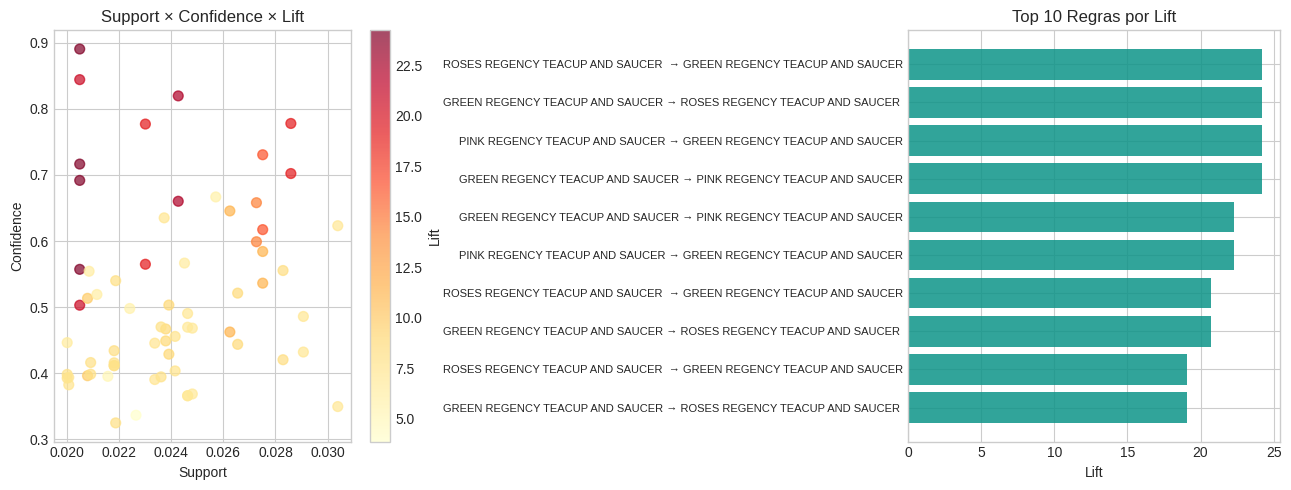

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Support vs Confidence, colorido por lift
sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', s=50, alpha=0.7
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support × Confidence × Lift')

# Top regras por lift
top10 = rules.head(10).copy()
top10['rule'] = top10.apply(
    lambda r: f"{', '.join(list(r['antecedents'])[:1])} → {', '.join(list(r['consequents'])[:1])}",
    axis=1
)
axes[1].barh(range(len(top10)), top10['lift'].values, color=GREEN, alpha=0.85)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10['rule'].values, fontsize=8)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Regras por Lift')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('/content/mba_rules.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 6 — COMPARAÇÃO APRIORI vs FP-GROWTH

In [14]:
import time

t0 = time.time()
fi_apriori = apriori(basket_bin, min_support=MIN_SUPPORT, use_colnames=True)
t_apriori = time.time() - t0

t0 = time.time()
fi_fpgrowth = fpgrowth(basket_bin, min_support=MIN_SUPPORT, use_colnames=True)
t_fpgrowth = time.time() - t0

print(f"\nApriori:   {len(fi_apriori)} itemsets em {t_apriori:.2f}s")
print(f"FP-Growth: {len(fi_fpgrowth)} itemsets em {t_fpgrowth:.2f}s")
# *** TAREFA: Os resultados são iguais? Qual é mais rápido? Porquê? ***


Apriori:   235 itemsets em 1.97s
FP-Growth: 235 itemsets em 4.04s


## PARTE 7 — EXPORTAR REGRAS PARA POWER BI

In [15]:
rules_export = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))
rules_export.to_csv('/content/regras_associacao.csv', index=False)

# Exportar também top produtos por frequência
top_products = (
    df_uk.groupby('Description')['Invoice']
    .nunique()
    .reset_index()
    .rename(columns={'Invoice': 'Num_Transacoes'})
    .sort_values('Num_Transacoes', ascending=False)
    .head(50)
)
top_products.to_csv('/content/top_produtos.csv', index=False)

print("\nFicheiros exportados: 'regras_associacao.csv', 'top_produtos.csv'")


Ficheiros exportados: 'regras_associacao.csv', 'top_produtos.csv'


> PERGUNTAS DE REFLEXÃO

In [13]:
# 1. Qual o efeito de duplicar o MIN_SUPPORT? E de o reduzir para metade?
#    Quais as implicações práticas para um retalhista?
#
# 2. Uma regra com lift=1.2 e confidence=0.9 é útil? Porquê?
#    Compara com uma regra lift=3.0 e confidence=0.4.
#
# 3. Identifica uma regra que pareça contraintuitiva.
#    Como a validarias junto de um especialista de negócio?
#
# 4. EXTENSÃO: Analisa as regras por País.
#    Os padrões de compra diferem entre o Reino Unido e a Alemanha?